# Freight Market Dynamics - Dry Van Market - VAR Models

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.stattools import grangercausalitytests

from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse, aic
from statsmodels.tsa.api import VAR

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Not use scientific notation

pd.set_option("display.float_format", "{:.4f}".format)

## Load data

In [4]:
df = pd.read_parquet("data/data_for_model.parquet") 
df = df[["id", "week", "r", "c", "f"]]

### Granger- Causality test

The basis behind Vector AutoRegression is that each of the time series in the  system influences each other. That is, you can predict the series with past 
values of itself along with other series in the system.

Using Granger’s Causality Test, it’s possible to test this relationship before even building the model.
* Ho: past values of time series (X) DO NOT cause the other series (Y).

In [5]:
def granger_causation_matrix(data, columns, p=4, test='ssr_chi2test', verbose=False):
    """
    Returns a matrix of min p-values from Granger tests for all ordered pairs.
    Rows are Y, columns are X (testing X -> Y). Smaller p => stronger evidence of Granger causality.
    """
    out_granger = pd.DataFrame(np.ones((len(columns), len(columns))),
                       columns=[v + "_x" for v in columns],
                       index=[v + "_y" for v in columns])
    for y in columns:
        for x in columns:
            if y == x: 
                out_granger.loc[y + "_y", x + "_x"] = np.nan
                continue
            # statsmodels expects first column = Y, second = X
            sub = data[[y, x]].dropna()
            if len(sub) <= p + 2:
                out_granger.loc[y + "_y", x + "_x"] = np.nan
                continue
            res = grangercausalitytests(sub, maxlag=p, verbose=False)
            pvals = [res[i+1][0][test][1] for i in range(p)]
            if verbose:
                print(f"Y={y}, X={x}, p-values by lag 1..{p}: {np.round(pvals,4)}")
            out_granger.loc[y + "_y", x + "_x"] = np.min(pvals)
    return out_granger


### Granger causality - One market area

In [6]:
vars_ = ['r','c','f']
df1 = df[df['id'] == 'CA_LAX'].sort_values('week')
gc_CA_LAX = granger_causation_matrix(df1[['r','c','f']], vars_, p=4)
gc_CA_LAX

,r_x,c_x,f_x
r_y,NaN,0.0000,0.0006
c_y,0.0074,NaN,0.0000
f_y,0.0000,0.0001,NaN


### Granger causality - All market areas

In [7]:
vars_ = ['r','c','f']
p = 4
alpha = 0.05

mats = {}
for group_id, d in df.sort_values('week').groupby('id'):
    mat = granger_causation_matrix(d[['r','c','f']], vars_, p=p)
    mats[group_id] = mat

# Stack into long form to summarize across ids
long = (pd.concat({k: v for k, v in mats.items()}, names=['id'])
          .stack().reset_index())
long.columns = ['id', 'y', 'x', 'pvalue']

# Share of panels where X -> Y is significant at alpha
share_sig = (long.assign(sig=lambda x: x['pvalue'] < alpha)
                  .groupby(['y','x'])['sig'].mean()
                  .unstack())
print("Fraction of IDs with significant Granger causality (p<0.05):")
share_sig

Fraction of IDs with significant Granger causality (p<0.05):


x,c_x,f_x,r_x
y,,,
c_y,NaN,1.0000,0.9259
f_y,1.0000,NaN,1.0000
r_y,1.0000,0.9630,NaN


### Stationary Test (ADF Test)

VAR model requires the time series you want to forecast to be stationary - ADF Test.

Differencing reduces the length of the series by 1 and since all the  time series has to be of the same length, you need to difference all the seriesin the system if you choose to difference at all.

In [8]:
## ADF test just for CA_LAX (df1)

id_test = 'CA_LAX'

def adf_one(series, autolag='AIC'):
    s = pd.to_numeric(pd.Series(series), errors='coerce').dropna()
    stat, p, nlags, nobs, crit, _ = adfuller(s, autolag=autolag)
    return {
        "test_stat": round(stat, 4),
        "pvalue": round(p, 4),
        "nlags": int(nlags),
        "nobs": int(nobs),
        "cv_1%": round(crit["1%"], 3),
        "cv_5%": round(crit["5%"], 3),
        "cv_10%": round(crit["10%"], 3),
        "stationary_5%": p < 0.05
    }

results = {col: adf_one(df1[col]) for col in vars_}
adf_table = pd.DataFrame(results).T

adf_table['id'] = id_test

adf_table

,test_stat,pvalue,nlags,nobs,cv_1%,cv_5%,cv_10%,stationary_5%,id
r,-1.4148,0.5751,3,222,-3.4600,-2.8750,-2.5740,False,CA_LAX
c,-1.2232,0.6635,15,210,-3.4620,-2.8750,-2.5740,False,CA_LAX
f,-0.6915,0.8489,1,224,-3.4600,-2.8750,-2.5740,False,CA_LAX


In [9]:
def adf_one(series, autolag='AIC'):
    s = pd.to_numeric(pd.Series(series), errors='coerce').dropna()
    stat, p, nlags, nobs, crit, _ = adfuller(s, autolag=autolag)
    return dict(test_stat=round(stat,4), pvalue=round(p,4),
                nlags=int(nlags), nobs=int(nobs),
                cv_1=round(crit['1%'],3), cv_5=round(crit['5%'],3),
                cv_10=round(crit['10%'],3), stationary_5=(p<0.05))

vars_ = ['r','c','f']
rows = []

for group_id, g in df.sort_values('week').groupby('id'):
    for v in vars_:
        rows.append({'id': group_id, 'var': v, **adf_one(g[v])})
panel_adf = pd.DataFrame(rows)

# share of IDs that are stationary at 5%
share = (panel_adf.groupby('var')['stationary_5']
                   .mean().rename('share_stationary')).reset_index()
print(share.round(3))

panel_adf

  var  share_stationary
0   c            0.0000
1   f            0.0000
2   r            0.0000


,id,var,test_stat,pvalue,nlags,nobs,cv_1,cv_5,cv_10,stationary_5
0,CA_LAX,r,-1.4148,0.5751,3,222,-3.4600,-2.8750,-2.5740,False
1,CA_LAX,c,-1.2232,0.6635,15,210,-3.4620,-2.8750,-2.5740,False
2,CA_LAX,f,-0.6915,0.8489,1,224,-3.4600,-2.8750,-2.5740,False
3,CA_ONT,r,-1.5349,0.5162,7,218,-3.4610,-2.8750,-2.5740,False
4,CA_ONT,c,-1.4928,0.5371,4,221,-3.4600,-2.8750,-2.5740,False
...,...,...,...,...,...,...,...,...,...,...
76,WI_GRE,c,0.4974,0.9848,3,222,-3.4600,-2.8750,-2.5740,False
77,WI_GRE,f,-0.6904,0.8492,4,221,-3.4600,-2.8750,-2.5740,False
78,WI_MIL,r,-1.5404,0.5134,3,222,-3.4600,-2.8750,-2.5740,False
79,WI_MIL,c,1.0619,0.9949,5,220,-3.4600,-2.8750,-2.5740,False


### ADF test results:
* Data are now stationary.
* IDs fail ADF and panel tests fail → We should difference or detrend:


### Compute First difference per id (KMA)



In [10]:
df.sort_values(by=['id', 'week'], inplace = True)

# Compute first differences
df[['r_d','c_d','f_d']] =df.groupby('id')[['r','c','f']].diff().dropna()

df_diff = df.dropna(subset=['r_d','c_d','f_d']).copy()

In [11]:
# Re-set vars for differenced data
vars_ = ['r_d','c_d','f_d']
rows = []

for group_id, g in df_diff.sort_values('week').groupby('id'):
    for v in vars_:
        rows.append({'id': group_id, 'var': v, **adf_one(g[v])})
        
panel_adf = pd.DataFrame(rows)


# share of IDs that are stationary at 5%
share = (panel_adf.groupby('var')['stationary_5']
                   .mean().rename('share_stationary')).reset_index()
print(share.round(3))
panel_adf


   var  share_stationary
0  c_d            0.3700
1  f_d            1.0000
2  r_d            1.0000


,id,var,test_stat,pvalue,nlags,nobs,cv_1,cv_5,cv_10,stationary_5
0,CA_LAX,r_d,-6.3889,0.0000,2,222,-3.4600,-2.8750,-2.5740,True
1,CA_LAX,c_d,-3.6941,0.0042,15,209,-3.4620,-2.8750,-2.5740,True
2,CA_LAX,f_d,-8.4771,0.0000,0,224,-3.4600,-2.8750,-2.5740,True
3,CA_ONT,r_d,-8.7899,0.0000,0,224,-3.4600,-2.8750,-2.5740,True
4,CA_ONT,c_d,-3.6413,0.0050,15,209,-3.4620,-2.8750,-2.5740,True
...,...,...,...,...,...,...,...,...,...,...
76,WI_GRE,c_d,0.6332,0.9884,3,221,-3.4600,-2.8750,-2.5740,False
77,WI_GRE,f_d,-5.7299,0.0000,3,221,-3.4600,-2.8750,-2.5740,True
78,WI_MIL,r_d,-7.2169,0.0000,2,222,-3.4600,-2.8750,-2.5740,True
79,WI_MIL,c_d,0.7916,0.9915,4,220,-3.4600,-2.8750,-2.5740,False


#### Note that capacity is still not fully stationary accross all KMAs. Need to diferentiate once again

In [13]:
# Compute second differences
df_diff[['r_d2','c_d2','f_d2']] =df_diff.groupby('id')[['r_d','c_d','f_d']].diff().dropna()

df_diff_2 = df_diff.dropna(subset=['r_d2','c_d2','f_d2']).copy()

In [14]:
# Re-set vars for differenced data
vars_ = ['r_d2','c_d2','f_d2']
rows = []

for group_id, g in df_diff_2.sort_values('week').groupby('id'):
    for v in vars_:
        rows.append({'id': group_id, 'var': v, **adf_one(g[v])})
        
panel_adf = pd.DataFrame(rows)


# share of IDs that are stationary at 5%
share = (panel_adf.groupby('var')['stationary_5']
                   .mean().rename('share_stationary')).reset_index()
print(share.round(3))
panel_adf


    var  share_stationary
0  c_d2            0.7780
1  f_d2            1.0000
2  r_d2            1.0000


,id,var,test_stat,pvalue,nlags,nobs,cv_1,cv_5,cv_10,stationary_5
0,CA_LAX,r_d2,-5.3093,0.0000,15,208,-3.4620,-2.8760,-2.5740,True
1,CA_LAX,c_d2,-3.3886,0.0114,15,208,-3.4620,-2.8760,-2.5740,True
2,CA_LAX,f_d2,-9.7486,0.0000,5,218,-3.4610,-2.8750,-2.5740,True
3,CA_ONT,r_d2,-5.4176,0.0000,15,208,-3.4620,-2.8760,-2.5740,True
4,CA_ONT,c_d2,-3.0010,0.0348,14,209,-3.4620,-2.8750,-2.5740,True
...,...,...,...,...,...,...,...,...,...,...
76,WI_GRE,c_d2,-2.4482,0.1286,2,221,-3.4600,-2.8750,-2.5740,False
77,WI_GRE,f_d2,-10.3156,0.0000,5,218,-3.4610,-2.8750,-2.5740,True
78,WI_MIL,r_d2,-8.0754,0.0000,11,212,-3.4620,-2.8750,-2.5740,True
79,WI_MIL,c_d2,-0.9902,0.7568,3,220,-3.4600,-2.8750,-2.5740,False


## PVAR FIXED Effects

In [16]:
# 1) Sort and within-demean by id
W = (df_diff_2
     .set_index(['id','week'])[vars_]
     .sort_index()
     .groupby(level=0)
     .apply(lambda x: x - x.mean())   # remove unit fixed effects
     .reset_index(level=0, drop=True))

display (W.head())

# # 1) Sort and within-demean by id
# W = (df_diff
#      .set_index(['id','week'])[vars_])


# 2) Fit pooled VAR with p=2
var = VAR(W.dropna())
res = var.fit(2)
print(res.summary())


r_d2    c_d2    f_d2
id     week                              
CA_LAX 2019-01-20  0.0063 -0.0055  0.0417
       2019-01-27  0.0660 -0.0047 -0.0150
       2019-02-03 -0.0458 -0.0041  0.0021
       2019-02-10  0.0607 -0.0035 -0.0127
       2019-02-17  0.0365 -0.0031  0.0199

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 22, Sep, 2025
Time:                     19:15:29
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -27.6195
Nobs:                     6046.00    HQIC:                  -27.6347
Log likelihood:           57848.6    FPE:                9.88263e-13
AIC:                     -27.6428    Det(Omega_mle):     9.84838e-13
--------------------------------------------------------------------
Results for equation r_d2
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const          -0.000014         0.000339           -0.040           0.968
L1.r_d2        -0.099540         0.012248           -8.127           0.000
L1.c_d2         0.378780         0.242848            1.560           0.119
L1.f_d2   

### VAR stability check

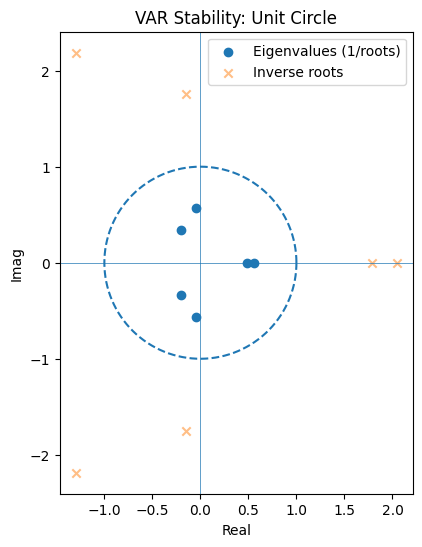

In [26]:
inv_roots = res.roots                    # inverse roots from statsmodels
eigvals   = 1 / inv_roots                # companion-matrix eigenvalues

theta = np.linspace(0, 2*np.pi, 512)

fig, ax = plt.subplots(figsize=(8,6))

# unit circle
ax.plot(np.cos(theta), np.sin(theta), linestyle='--')

# plot eigenvalues
ax.scatter(eigvals.real, eigvals.imag, marker='o', label='Eigenvalues (1/roots)')

# (optional) also show inverse roots (should be OUTSIDE unit circle if stable)
ax.scatter(inv_roots.real, inv_roots.imag, marker='x', alpha=0.5, label='Inverse roots')

ax.axhline(0, linewidth=0.5); ax.axvline(0, linewidth=0.5)
ax.set_aspect('equal', 'box')
ax.set_xlabel('Real'); ax.set_ylabel('Imag')
ax.set_title('VAR Stability: Unit Circle')
ax.legend()
plt.show()


### IRF Intuition (Stationary VAR)

In general, if the IRFs are positive, it indicates a positive shock on the variable. This shock will die out after a few time periods and IRFs will fall back to zero in a Stationary VAR. 

On the other hand, if the IRFs are negative, it indicates a negative shock and the IRfs will rise back to zero after a few periods in a stationary VAR model.

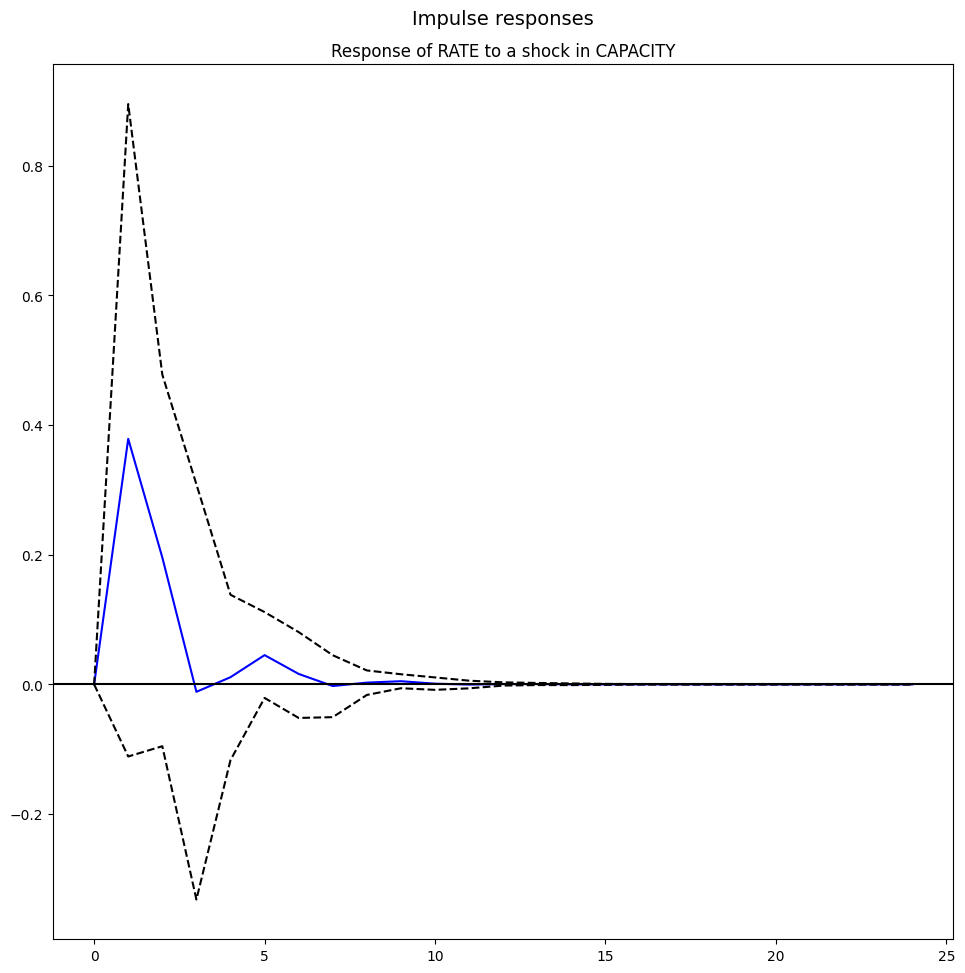

In [32]:
# Plot individual IRFs 

irf = res.irf(periods=24) 

irf.plot(impulse='c_d2', response='r_d2', plot_stderr=True, stderr_type='mc', repl=1000)

plt.title('Response of RATE to a shock in CAPACITY')
plt.show()

In [34]:
# Access the numerical results of the IRFs
# irf.irfs: array of IRF values
# irf.stderr: array of standard errors
# irf.lower_err_bands, irf.upper_err_bands: confidence bands
print("IRF values (first 5 periods for response of rate to capacity shock):")
print(irf.irfs[:, 0, 1][:5]) # Accessing specific IRF values

IRF values (first 5 periods for response of rate to capacity shock):
[ 0.          0.37878026  0.19584536 -0.01143644  0.01112235]


### Plot all IRFs pairs

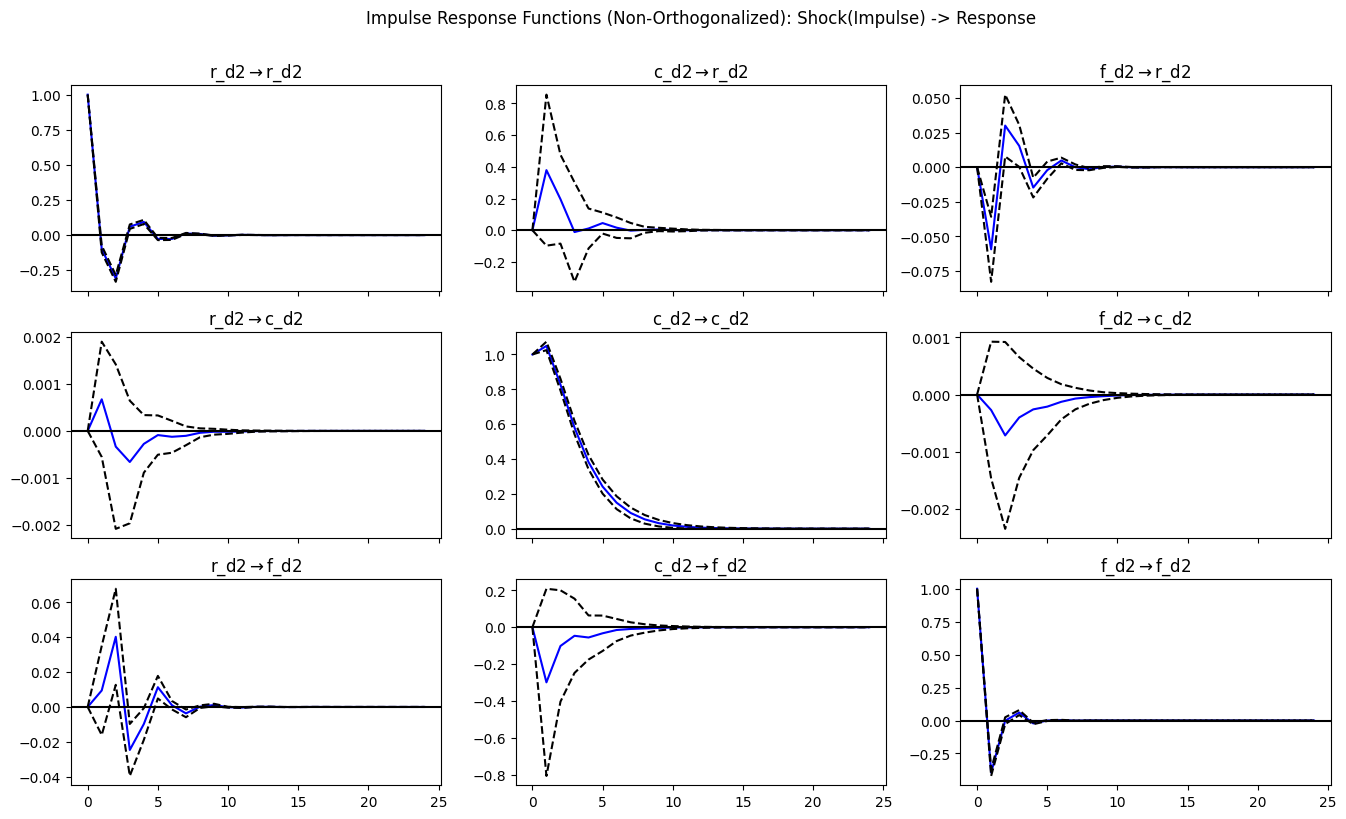

In [45]:
irf = res.irf(periods=24) 

# Remember that Cholesky decomposition is default for orth=True) - assuming a specific ordering of variables.
irf.plot(orth=False, figsize=(14,8)) # Plot IRFs, non-orthogonalized - socks are not assumed to be uncorrelated.(

# Remember that Cholesky decomposition is default for orth=True)
plt.suptitle('Impulse Response Functions (Non-Orthogonalized): Shock(Impulse) -> Response', y=1.02)
plt.show()